In [4]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words = open('names.txt','r',).read().splitlines()

building a bigram model
bigram -> only concerned with 2 characters at a time

In [ ]:
for w in words:
    for ch1, ch2 in zip(w,w[1:]):
        print(ch1,ch2)

In [ ]:
w = words[0]
list(w)

#print(words[:10])

In [6]:
N = torch.zeros((27,27), dtype = torch.int32) # 26 alphabets+ E,S symbols



In [7]:
#lookup table for all chars

chars =sorted(list(set(''.join(words)))) # set removes duplicates
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['<.>'] = 0
itos = {i:s for s,i in stoi.items()}




In [8]:

for w in words:
    chs = ['<.>'] + list(w) + ['<.>']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1

In [ ]:
itos = {i:s for s,i in stoi.items()}
itos

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

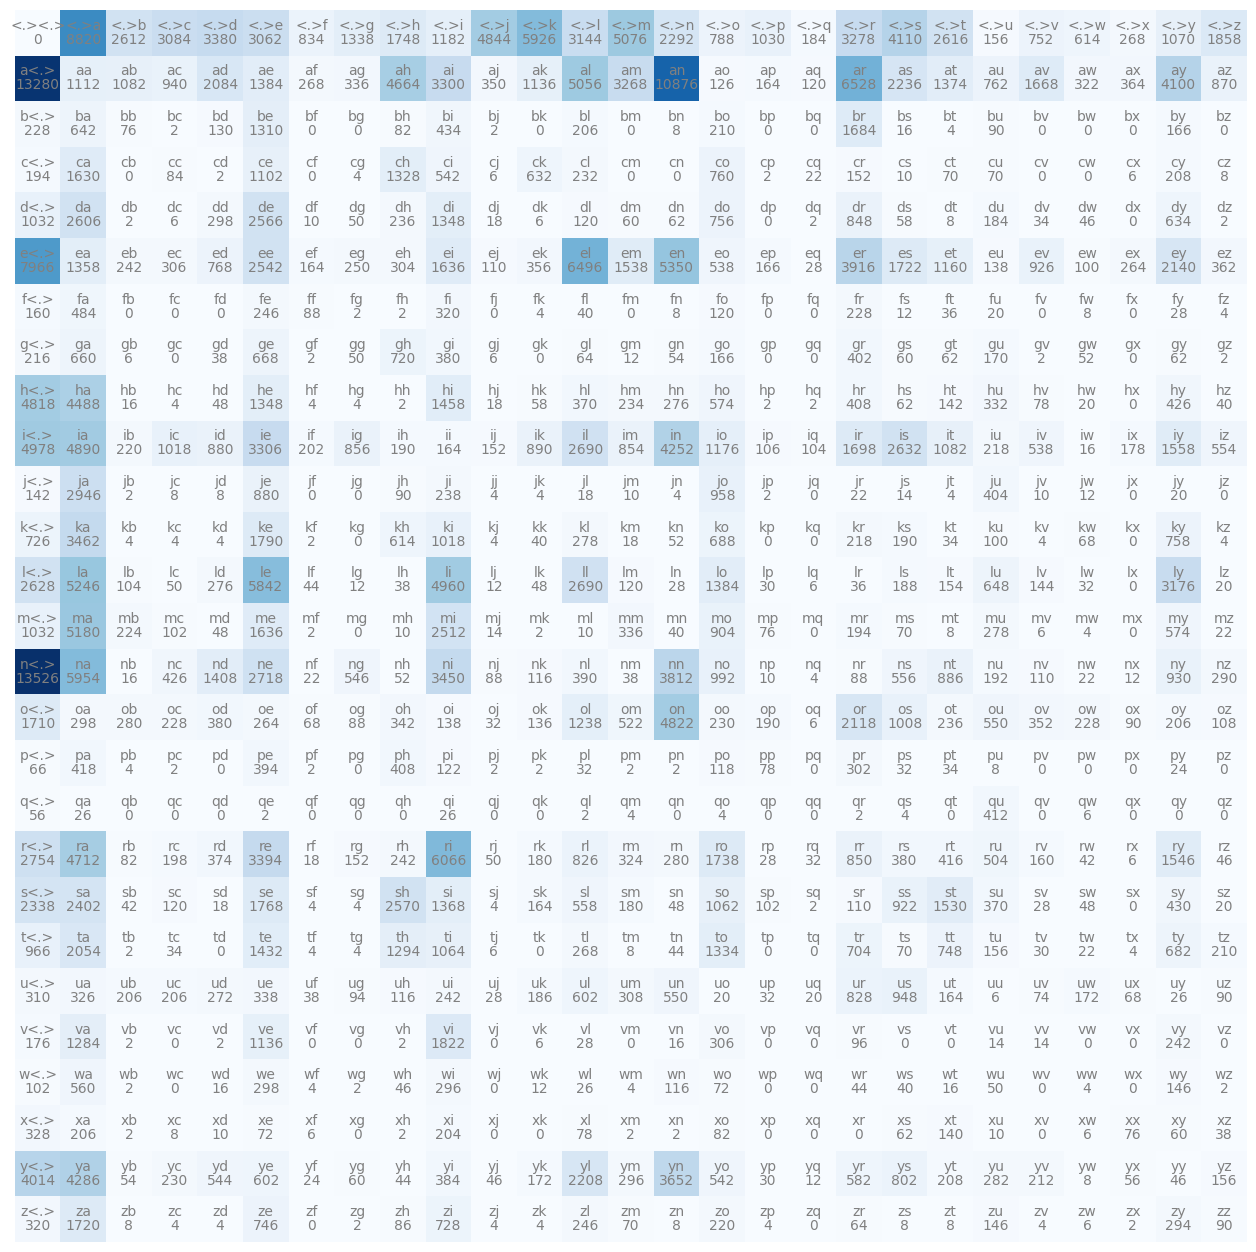

In [25]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i]+itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color = "gray")
        plt.text(j,i,N[i,j].item(),ha = "center", va  = 'top',color = 'gray')
plt.axis('off')        


In [46]:
P = N.float()
P/= P.sum(1, keepdim =True)

In [38]:
p = N[0].float()
p /=p.sum()
p.sum()

tensor(1.)

### building a random prob distribution, then sampling from it


In [11]:

g=torch.Generator().manual_seed(42)
ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sample indices from p
itos[ix]

'a'

In [12]:
g=torch.Generator().manual_seed(42)
p=torch.rand(3, generator=g) # 3 rand nos from 0 to 1
p=p/p.sum() # normalize the 3 rand nos to add up to 1
p # now p is a probability vector

tensor([0.4047, 0.4197, 0.1756])

In [13]:
torch.multinomial(p,20,replacement =True,generator =g)# sample indices from p


tensor([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 2])

In [ ]:
g=torch.Generator().manual_seed(42)
for i in range(5):

    out = []
    ix = 0 # init index at <.>

    while True:
        p = P[ix]
       
        ix = torch.multinomial(p,1,replacement =True,generator =g).item()# sampling the next character from the distribution
        out.append(itos[ix])
    
        if ix==0: # after sampling the end token end the loop
            break  
    print(''.join(out))      


anugeenvi<.>
s<.>
mabian<.>
dan<.>
stan<.>
